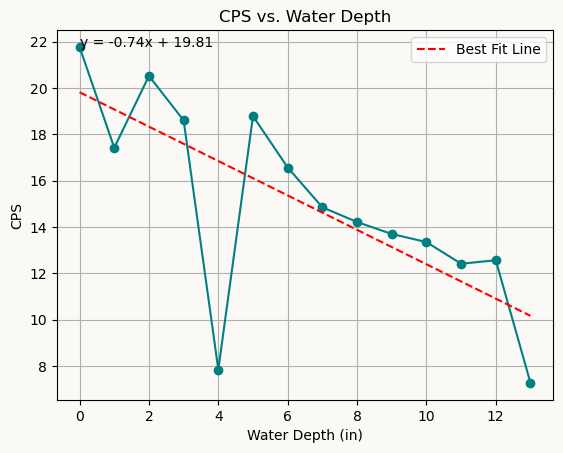

In [7]:
# raw data
import matplotlib.pyplot as plt
import numpy as np

x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] #13 is all water but no source
y = [
    21.76666667, 17.41666667, 20.51666667, 18.6, 7.85,
    18.78333333, 16.56666667, 14.85, 14.21666667, 13.7,
    13.35, 12.41666667, 12.56666667, 7.276470588
]

fig, ax = plt.subplots()

fig.set_facecolor("#fbf9f5")   
ax.set_facecolor("#fbf9f5") 

m, b = np.polyfit(x, y, 1)
y_fit = [m * xi + b for xi in x]

plt.text(0, max(y), f"y = {m:.2f}x + {b:.2f}")

plt.plot(x, y, marker='o', linestyle='-', color='teal')

plt.plot(x, y_fit, color='red', linestyle='--', label='Best Fit Line')

plt.xlabel("Water Depth (in)")
plt.ylabel("CPS")
plt.title("CPS vs. Water Depth")

plt.grid(True)

plt.legend()

plt.show()

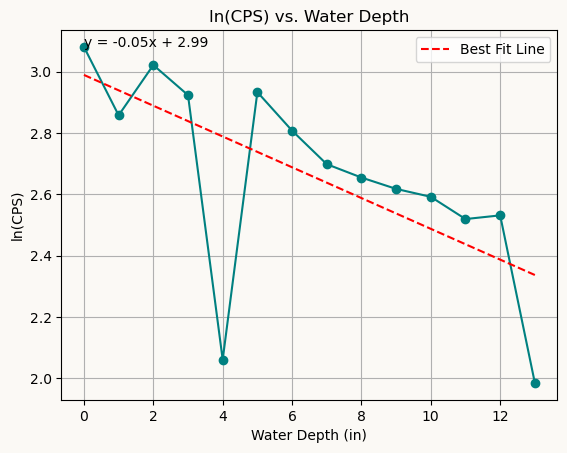

In [12]:
# linearized data
import matplotlib.pyplot as plt
import numpy as np

x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] #13 is all water but no source
y = [
    3.080379748, 2.857427602, 3.021238, 2.923161581, 2.060513532,
    2.932969952, 2.807392645, 2.697999865, 2.654414986, 2.617395833,
    2.591516385, 2.519039656, 2.531047806, 1.984645935
]

fig, ax = plt.subplots()

fig.set_facecolor("#fbf9f5")   
ax.set_facecolor("#fbf9f5") 

m, b = np.polyfit(x, y, 1)
y_fit = [m * xi + b for xi in x]

plt.text(0, max(y), f"y = {m:.2f}x + {b:.2f}")

plt.plot(x, y, marker='o', linestyle='-', color='teal')

plt.plot(x, y_fit, color='red', linestyle='--', label='Best Fit Line')

plt.xlabel("Water Depth (in)")
plt.ylabel("ln(CPS)")
plt.title("ln(CPS) vs. Water Depth")

plt.grid(True)

plt.legend()

plt.show()

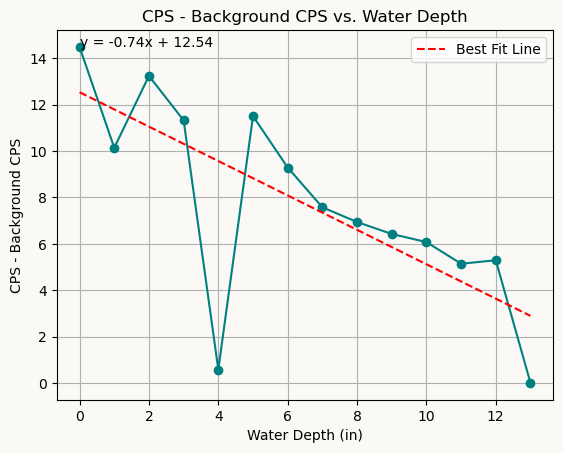

In [13]:
# raw data - background cps
import matplotlib.pyplot as plt
import numpy as np

x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] #13 is all water but no source
y = [
    14.49019608,
    10.14019608,
    13.24019608,
    11.32352941,
    0.573529412,
    11.50686274,
    9.290196082,
    7.573529412,
    6.940196082,
    6.423529412,
    6.073529412,
    5.140196082,
    5.290196082,
    0
]

fig, ax = plt.subplots()

fig.set_facecolor("#fbf9f5")   
ax.set_facecolor("#fbf9f5") 

m, b = np.polyfit(x, y, 1)
y_fit = [m * xi + b for xi in x]

plt.text(0, max(y), f"y = {m:.2f}x + {b:.2f}")

plt.plot(x, y, marker='o', linestyle='-', color='teal')

plt.plot(x, y_fit, color='red', linestyle='--', label='Best Fit Line')

plt.xlabel("Water Depth (in)")
plt.ylabel("CPS - Background CPS")
plt.title("CPS - Background CPS vs. Water Depth")

plt.grid(True)

plt.legend()

plt.show()

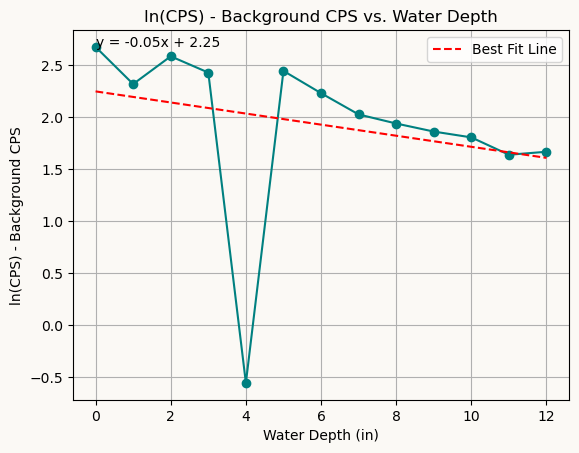

In [14]:
# linearized data - background cps
import matplotlib.pyplot as plt
import numpy as np

x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] #13 is all water but no source
y = [
    2.673472288,
    2.316507335,
    2.58325736,
    2.42688281,
    -0.555946059,
    2.442943618,
    2.228959659,
    2.024659196,
    1.937330028,
    1.859967719,
    1.803939888,
    1.637091227,
    1.665855312,
]

fig, ax = plt.subplots()

fig.set_facecolor("#fbf9f5")   
ax.set_facecolor("#fbf9f5") 

m, b = np.polyfit(x, y, 1)
y_fit = [m * xi + b for xi in x]

plt.text(0, max(y), f"y = {m:.2f}x + {b:.2f}")

plt.plot(x, y, marker='o', linestyle='-', color='teal')

plt.plot(x, y_fit, color='red', linestyle='--', label='Best Fit Line')

plt.xlabel("Water Depth (in)")
plt.ylabel("ln(CPS) - Background CPS")
plt.title("ln(CPS) - Background CPS vs. Water Depth")

plt.grid(True)

plt.legend()

plt.show()

In [15]:
import numpy as np
from scipy import stats

# Your depth and ln(CPS) values
depth_cm = np.array([0, 2.54, 5.08, 7.62, 12.70, 15.24, 17.78, 20.32, 22.86, 25.40, 27.94, 30.48])

# Background-corrected CPS (excluding depth-4 anomaly)
corrected_cps = np.array([14.491, 10.141, 13.241, 11.324, 11.507, 9.291, 7.574, 6.941, 6.424, 6.074, 5.141, 5.291])

# Linearize
ln_cps = np.log(corrected_cps)

# Pearson correlation
r, p = stats.pearsonr(depth_cm, ln_cps)
print(f"Pearson r = {r:.4f}")
print(f"P-value   = {p:.6f}")

# Linear regression (gives slope = -mu, intercept = ln(I0))
slope, intercept, r_value, p_value, std_err = stats.linregress(depth_cm, ln_cps)
print(f"\nSlope (-mu) = {slope:.5f} ± {std_err:.5f} cm⁻¹")
print(f"Intercept   = {intercept:.4f}")
print(f"R²          = {r_value**2:.4f}")

# T-statistic
n = len(depth_cm)
t_stat = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
print(f"\nT-statistic = {t_stat:.4f}")
print(f"DOF         = {n - 2}")

Pearson r = -0.9498
P-value   = 0.000002

Slope (-mu) = -0.03339 ± 0.00348 cm⁻¹
Intercept   = 2.6566
R²          = 0.9022

T-statistic = -9.6021
DOF         = 10


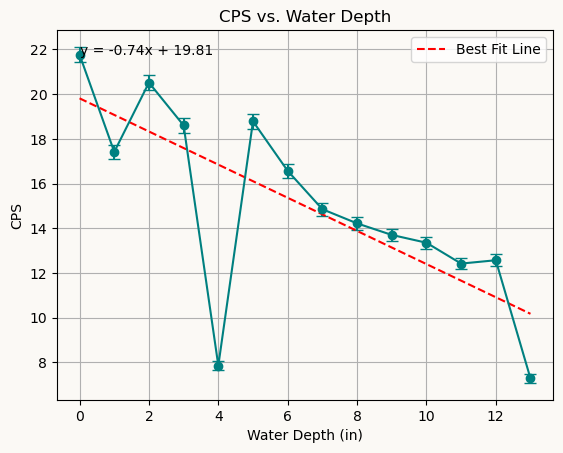

In [16]:
import matplotlib.pyplot as plt
import numpy as np

x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

y = [
    21.76666667, 17.41666667, 20.51666667, 18.6, 7.85,
    18.78333333, 16.56666667, 14.85, 14.21666667, 13.7,
    13.35, 12.41666667, 12.56666667, 7.276470588
]

# --- ADD THIS ---
time = 180  # seconds (change if different)

y = np.array(y)

# reconstruct counts
counts = y * time

# Poisson error
y_error = np.sqrt(counts) / time
# --- END ADD ---

fig, ax = plt.subplots()

fig.set_facecolor("#fbf9f5")   
ax.set_facecolor("#fbf9f5") 

m, b = np.polyfit(x, y, 1)
y_fit = [m * xi + b for xi in x]

plt.text(0, max(y), f"y = {m:.2f}x + {b:.2f}")

# --- REPLACE YOUR PLOT LINE WITH THIS ---
plt.errorbar(x, y, yerr=y_error, fmt='o', linestyle='-', color='teal', capsize=4)
# --- END CHANGE ---

plt.plot(x, y_fit, color='red', linestyle='--', label='Best Fit Line')

plt.xlabel("Water Depth (in)")
plt.ylabel("CPS")
plt.title("CPS vs. Water Depth")

plt.grid(True)
plt.legend()

plt.show()

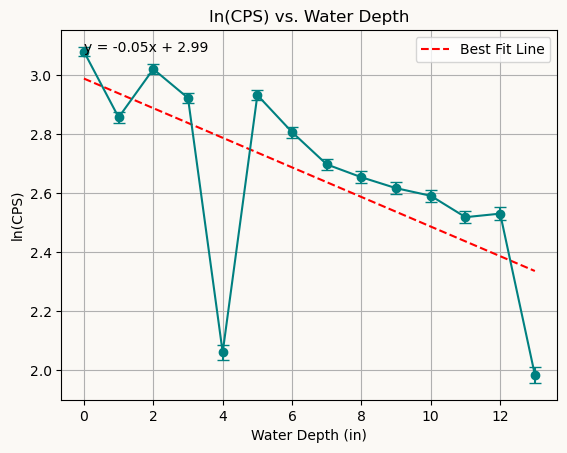

Attenuation coefficient μ = 0.05019047245274741


In [19]:
import matplotlib.pyplot as plt
import numpy as np

x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

y = [
    3.080379748, 2.857427602, 3.021238, 2.923161581, 2.060513532,
    2.932969952, 2.807392645, 2.697999865, 2.654414986, 2.617395833,
    2.591516385, 2.519039656, 2.531047806, 1.984645935
]

# --- ADD THIS ---
time = 180  # seconds (change if needed)

y = np.array(y)

# Convert back to CPS
cps = np.exp(y)

# Reconstruct counts
counts = cps * time

# CPS uncertainty
cps_error = np.sqrt(counts) / time

# Propagate error: σ_ln = σ / value
y_error = cps_error / cps
# --- END ADD ---

fig, ax = plt.subplots()

fig.set_facecolor("#fbf9f5")   
ax.set_facecolor("#fbf9f5") 

m, b = np.polyfit(x, y, 1)
y_fit = [m * xi + b for xi in x]

plt.text(0, max(y), f"y = {m:.2f}x + {b:.2f}")

# --- REPLACE THIS LINE ---
plt.errorbar(x, y, yerr=y_error, fmt='o', linestyle='-', capsize=4, color='teal')
# --- END CHANGE ---

plt.plot(x, y_fit, color='red', linestyle='--', label='Best Fit Line')

plt.xlabel("Water Depth (in)")
plt.ylabel("ln(CPS)")
plt.title("ln(CPS) vs. Water Depth")

plt.grid(True)
plt.legend()

plt.show()

# Optional: print attenuation coefficient
mu = -m
print("Attenuation coefficient μ =", mu)

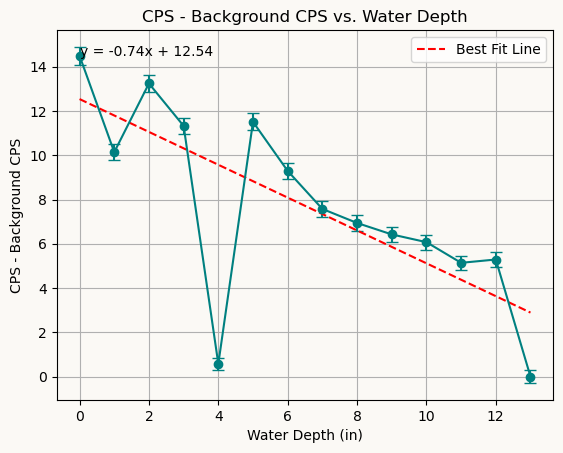

In [21]:
import matplotlib.pyplot as plt
import numpy as np

x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

y = [
    14.49019608,
    10.14019608,
    13.24019608,
    11.32352941,
    0.573529412,
    11.50686274,
    9.290196082,
    7.573529412,
    6.940196082,
    6.423529412,
    6.073529412,
    5.140196082,
    5.290196082,
    0
]

# --- ADD THIS ---
time = 180  # seconds (change if needed)

y = np.array(y)

# Estimate original signal (before subtraction)
# (Add background back in — you need your actual background value here)
background_cps = 7.276470588  # <-- replace with YOUR measured background

signal_cps = y + background_cps

# Convert to counts
signal_counts = signal_cps * time
background_counts = background_cps * time

# Uncertainties
sigma_signal = np.sqrt(signal_counts) / time
sigma_background = np.sqrt(background_counts) / time

# Combine uncertainties
y_error = np.sqrt(sigma_signal**2 + sigma_background**2)
# --- END ADD ---

fig, ax = plt.subplots()

fig.set_facecolor("#fbf9f5")   
ax.set_facecolor("#fbf9f5") 

m, b = np.polyfit(x, y, 1)
y_fit = [m * xi + b for xi in x]

plt.text(0, max(y), f"y = {m:.2f}x + {b:.2f}")

# --- REPLACE THIS ---
plt.errorbar(x, y, yerr=y_error, fmt='o', linestyle='-', capsize=4, color='teal')
# --- END CHANGE ---

plt.plot(x, y_fit, linestyle='--', label='Best Fit Line', color='red')

plt.xlabel("Water Depth (in)")
plt.ylabel("CPS - Background CPS")
plt.title("CPS - Background CPS vs. Water Depth")

plt.grid(True)
plt.legend()

plt.show()

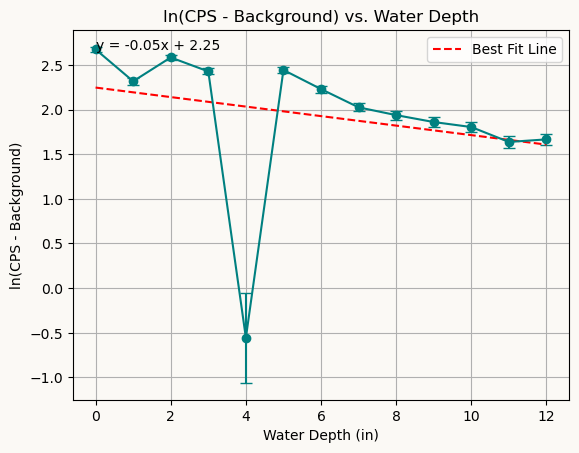

Attenuation coefficient μ = 0.053255658269230725


In [23]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])

y = np.array([
    2.673472288,
    2.316507335,
    2.58325736,
    2.42688281,
    -0.555946059,
    2.442943618,
    2.228959659,
    2.024659196,
    1.937330028,
    1.859967719,
    1.803939888,
    1.637091227,
    1.665855312,
])

# --- ADD THIS ---
time = 180  # seconds (change if needed)
background_cps = 7.276470588  # replace if needed

# Convert back from log → (signal - background)
I = np.exp(y)

# Remove invalid (negative / near-zero) points
mask = I > 0

x_valid = x[mask]
y_valid = y[mask]
I_valid = I[mask]

# Reconstruct signal (add background back)
signal_cps = I_valid + background_cps

# Convert to counts
signal_counts = signal_cps * time
background_counts = background_cps * time

# Uncertainties
sigma_signal = np.sqrt(signal_counts) / time
sigma_background = np.sqrt(background_counts) / time

# Combine uncertainties
sigma_I = np.sqrt(sigma_signal**2 + sigma_background**2)

# Propagate through log
y_error = sigma_I / I_valid
# --- END ADD ---

fig, ax = plt.subplots()

fig.set_facecolor("#fbf9f5")   
ax.set_facecolor("#fbf9f5") 

# Fit ONLY valid points
m, b = np.polyfit(x_valid, y_valid, 1)
y_fit = [m * xi + b for xi in x_valid]

plt.text(0, max(y_valid), f"y = {m:.2f}x + {b:.2f}")

# --- REPLACE THIS ---
plt.errorbar(x_valid, y_valid, yerr=y_error, fmt='o', linestyle='-', capsize=4, color='teal')
# --- END CHANGE ---

plt.plot(x_valid, y_fit, linestyle='--', label='Best Fit Line', color='red')

plt.xlabel("Water Depth (in)")
plt.ylabel("ln(CPS - Background)")
plt.title("ln(CPS - Background) vs. Water Depth")

plt.grid(True)
plt.legend()

plt.show()

# Optional: attenuation coefficient
mu = -m
print("Attenuation coefficient μ =", mu)

In [25]:
import numpy as np
from scipy.optimize import curve_fit
from scipy import stats

# Background-corrected CPS (depth-4 anomaly excluded)
depth_cm = np.array([0, 2.54, 5.08, 7.62, 12.70, 15.24, 17.78, 20.32, 22.86, 25.40, 27.94, 30.48])
corrected_cps = np.array([14.491, 10.141, 13.241, 11.324, 11.507, 9.291, 7.574, 6.941, 6.424, 6.074, 5.141, 5.291])

# --- METHOD 1: Direct exponential fit ---
def exp_model(x, I0, mu):
    return I0 * np.exp(-mu * x)

popt, pcov = curve_fit(exp_model, depth_cm, corrected_cps, p0=[15, 0.05])
I0_fit, mu_fit = popt
I0_err, mu_err = np.sqrt(np.diag(pcov))

print("Exponential Fit:")
print(f"I0  = {I0_fit:.4f} CPS")
print(f"mu  = {mu_fit:.5f} ± {mu_err:.5f} cm⁻¹")
print(f"HVL = {np.log(2)/mu_fit:.2f} cm")

# --- METHOD 2: Linearized fit (ln(CPS) vs depth) ---
ln_cps = np.log(corrected_cps)
slope, intercept, r_value, p_value, std_err = stats.linregress(depth_cm, ln_cps)

print("\nLinearized Fit:")
print(f"mu  = {-slope:.5f} ± {std_err:.5f} cm⁻¹")
print(f"I0  = {np.exp(intercept):.4f} CPS")
print(f"R²  = {r_value**2:.4f}")
print(f"HVL = {np.log(2)/(-slope):.2f} cm")

Exponential Fit:
I0  = 13.9986 CPS
mu  = 0.03144 ± 0.00429 cm⁻¹
HVL = 22.04 cm

Linearized Fit:
mu  = 0.03339 ± 0.00348 cm⁻¹
I0  = 14.2471 CPS
R²  = 0.9022
HVL = 20.76 cm
